In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import ast
from scipy import stats

In [2]:
#initalize the dataframes
df_freecontrol = pd.read_csv('experiments/control.csv', converters={'id_correct': ast.literal_eval})
df_freeprimacy = pd.read_csv('experiments/primacy.csv', converters={'id_correct': ast.literal_eval})
df_freerecency = pd.read_csv('experiments/recency.csv', converters={'id_correct': ast.literal_eval})
df_freewait = pd.read_csv('experiments/wait.csv', converters={'id_correct': ast.literal_eval})
df_serial = pd.read_csv('experiments/serial_recall.csv')
df_serialchunking = pd.read_csv('experiments/serial_recall_chunking.csv')
df_serialtahdah = pd.read_csv('experiments/serial_recall_tahdah.csv')
df_serialtapping = pd.read_csv('experiments/serial_recall_tapping.csv')

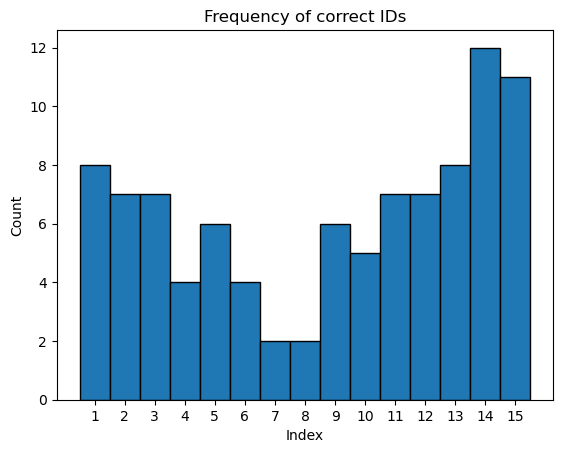

In [3]:
col = df_freecontrol['id_correct']
all_vals = np.concatenate(col.tolist()) 

bins = np.arange(1, 17) - 0.5
plt.hist(all_vals, bins=bins, edgecolor="black")
plt.xticks(range(1, 16))
plt.xlabel("Index")
plt.ylabel("Count")
plt.title("Frequency of correct IDs")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

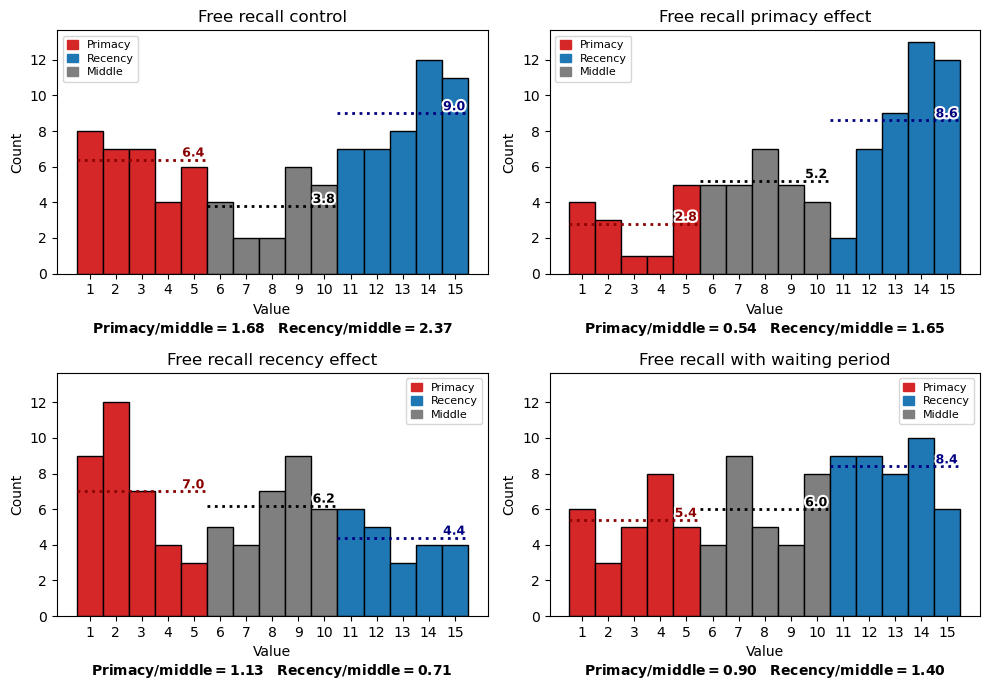

In [4]:
datasets = [
    ("Free recall control",  df_freecontrol),
    ("Free recall primacy effect",        df_freeprimacy),
    ("Free recall recency effect",        df_freerecency),
    ("Free recall with waiting period",        df_freewait),
]

def to_list(x):
    return ast.literal_eval(x) if isinstance(x, str) else x

bins = np.arange(1, 17) - 0.5

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=True)

for ax, (name, df) in zip(axes.flat, datasets):
    arrays = df["id_correct"].dropna().apply(to_list)
    all_vals = np.concatenate(arrays.tolist())

    n, edges, patches = ax.hist(all_vals, bins=bins, edgecolor="black")
    for p in patches[:5]:
        p.set_facecolor("tab:red")
    for p in patches[-5:]:
        p.set_facecolor("tab:blue")
    for p in patches[5:10]:
        p.set_facecolor("tab:grey")
    ax.set_title(name)
    ax.set_xticks(range(1, 16))

    groups = [
        (slice(0, 5),   edges[0],  edges[5],  "darkred"),
        (slice(5, 10),  edges[5],  edges[10], "black"),
        (slice(10, 15), edges[10], edges[15], "navy"),
    ]
    for s, x0, x1, c in groups:
        avg = n[s].mean()
        ax.hlines(avg, x0, x1, colors=c, linestyles=":", linewidth=2, zorder=3)
        ax.text(x1 - 0.1, avg, f"{avg:.1f}", color=c, fontweight="bold",
        ha="right", va="bottom", fontsize=9, zorder=4,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")])

    red_vs_middle = n[:5].sum() / n[5:10].sum()
    blue_vs_middle = n[10:].sum() / n[5:10].sum()
    
    ax.set_ylabel("Count")
    ax.set_xlabel(
    "Value\n" + rf"$\mathbf{{Primacy / middle = {red_vs_middle:.2f}}}$   "
                rf"$\mathbf{{Recency / middle = {blue_vs_middle:.2f}}}$"
)
    ax.tick_params(labelbottom=True, labelleft=True)
    ax.legend(handles=[
    Patch(color="tab:red", label="Primacy"),
    Patch(color="tab:blue", label="Recency"),
    Patch(color="tab:grey", label="Middle"),
    ],
    fontsize=8,           # smaller text
    handlelength=1,       # shorter color swatches
    handleheight=0.8,     # shorter swatch height
    borderpad=0.4,        # less padding inside the box
    labelspacing=0.3,     # less space between entries
    )
    

fig.tight_layout()


plt.show

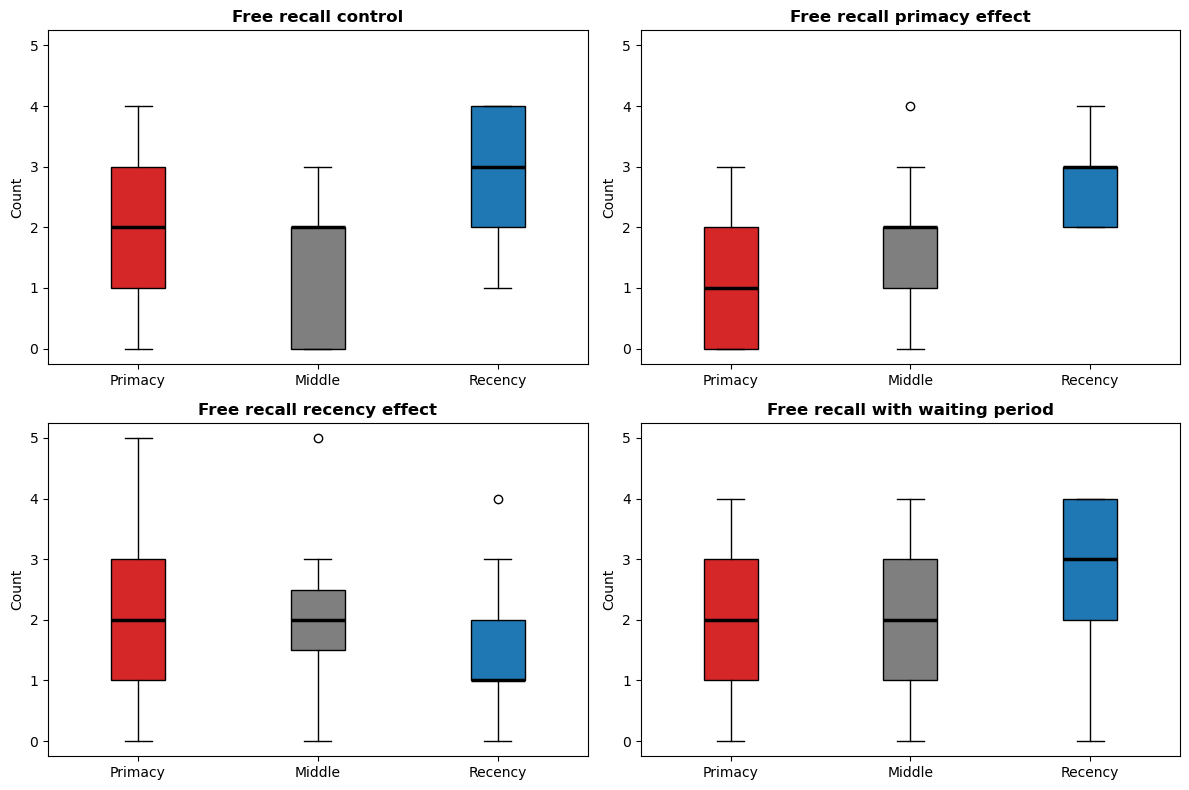

In [5]:
def row_counts(arr):
    arr = np.asarray(arr)
    return (
        np.sum(arr <= 5),                    # 1-5
        np.sum((arr >= 6) & (arr <= 10)),    # 6-10
        np.sum(arr >= 11),                   # 11-15
    )

colors = ["tab:red", "tab:grey", "tab:blue"]
labels = ["Primacy", "Middle", "Recency"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for ax, (name, df) in zip(axes.flat, datasets):
    arrays = df["id_correct"].dropna().apply(to_list)
    arrays = [a for a in arrays if len(a) > 0]           # drop empty rows
    counts = np.array([row_counts(a) for a in arrays])   # shape (n_rows, 3)

    bp = ax.boxplot(
        counts, tick_labels=labels, patch_artist=True,
        medianprops=dict(color="black", linewidth=2.5, solid_capstyle="butt"),
    )
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_edgecolor("black")
        box.set_linewidth(1)                 # thin border so it doesn't swallow the median
    for med in bp["medians"]:
        med.set_zorder(5)                    # draw median on top of everything

    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Count")
    ax.tick_params(labelleft=True)

fig.tight_layout()
plt.show()

                  dataset  n_rows  mean  ci_low  ci_high
0   Serial recall control      15  5.73    4.83     6.63
1  Serial recall chunking      15  5.47    4.63     6.30
2   Serial recall tah-dah      15  5.20    4.17     6.23
3   Serial recall tapping      15  6.07    5.27     6.86


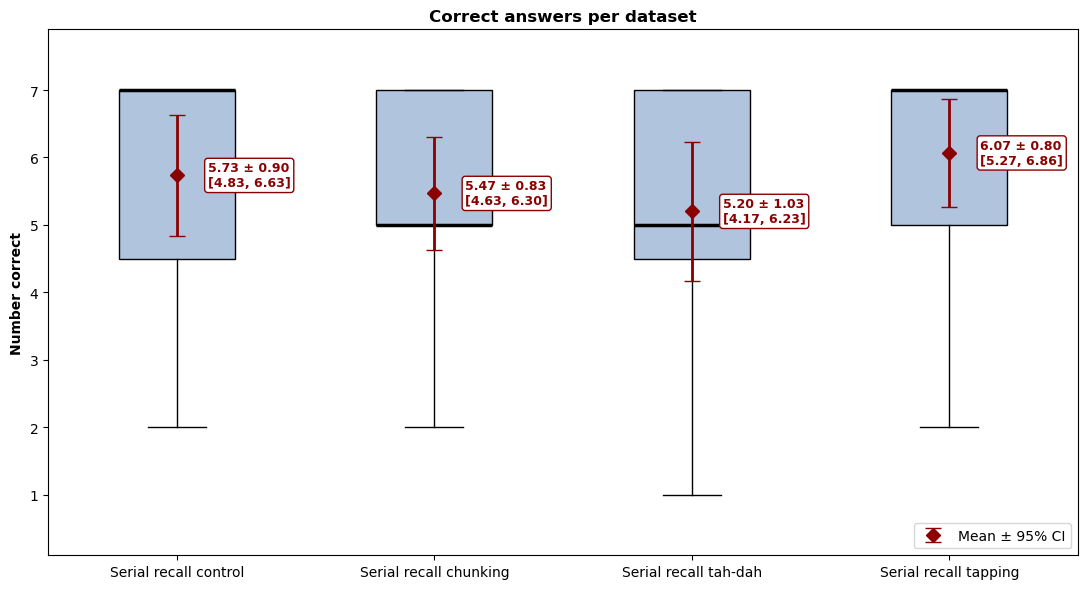

In [7]:
files = [
    ("Serial recall control", "experiments/serial_recall.csv"),
    ("Serial recall chunking",       "experiments/serial_recall_chunking.csv"),
    ("Serial recall tah-dah",       "experiments/serial_recall_tahdah.csv"),
    ("Serial recall tapping",       "experiments/serial_recall_tapping.csv"),
]

def mean_ci(x, conf=0.95):
    x = np.asarray(x, dtype=float)
    m = x.mean()
    if len(x) < 2:
        return m, np.nan, np.nan
    se = stats.sem(x)
    if se == 0:
        return m, m, m
    lo, hi = stats.t.interval(conf, df=len(x) - 1, loc=m, scale=se)
    return m, lo, hi

names, data, rows = [], [], []
for title, path in files:
    vals = pd.read_csv(path)["n_correct"].to_numpy()
    names.append(title)
    data.append(vals)
    m, lo, hi = mean_ci(vals)
    rows.append({"dataset": title, "n_rows": len(vals), "mean": m, "ci_low": lo, "ci_high": hi})

print(pd.DataFrame(rows).round(2))

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(
    data, tick_labels=names, patch_artist=True,
    medianprops=dict(color="black", linewidth=2.5, solid_capstyle="butt"),
)
for box in bp["boxes"]:
    box.set_facecolor("lightsteelblue")
    box.set_edgecolor("black")
for med in bp["medians"]:
    med.set_zorder(5)

# mean + 95% CI on top of each box
pos = np.arange(1, len(data) + 1)
means = np.array([r["mean"] for r in rows])
lo = np.array([r["ci_low"] for r in rows])
hi = np.array([r["ci_high"] for r in rows])
ax.errorbar(pos, means, yerr=[means - lo, hi - means], fmt="D", color="darkred",
            ecolor="darkred", elinewidth=2, capsize=6, markersize=7,
            zorder=6, label="Mean ± 95% CI")

# label each diamond with the mean and the +- half-width of the CI
for x, m, l, h in zip(pos, means, lo, hi):
    if np.isnan(l):
        txt = f"{m:.2f}\n(CI n/a)"
    else:
        half = (h - l) / 2
        txt = f"{m:.2f} ± {half:.2f}\n[{l:.2f}, {h:.2f}]"
    ax.text(x + 0.12, m, txt, ha="left", va="center", fontsize=9,
            fontweight="bold", color="darkred", zorder=7,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor="darkred", linewidth=1))

ax.set_ylabel("Number correct", fontweight="bold")
ax.set_title("Correct answers per dataset", fontweight="bold")
ax.margins(y=0.15)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

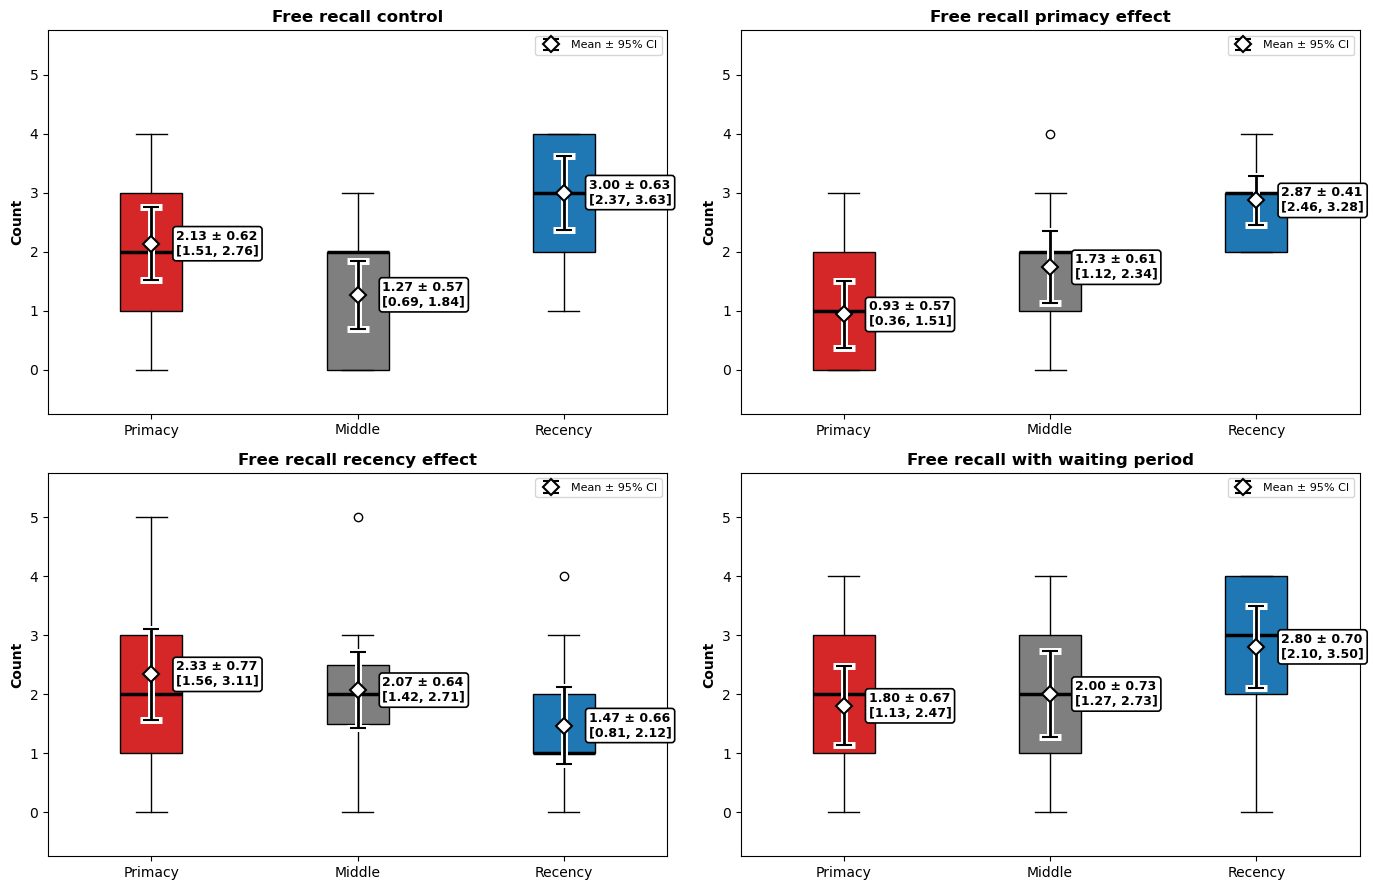

In [9]:
def row_counts(arr):
    arr = np.asarray(arr)
    return (
        np.sum(arr <= 5),                    # 1-5
        np.sum((arr >= 6) & (arr <= 10)),    # 6-10
        np.sum(arr >= 11),                   # 11-15
    )

def mean_ci(x, conf=0.95):
    x = np.asarray(x, dtype=float)
    m = x.mean()
    if len(x) < 2:
        return m, np.nan, np.nan
    se = stats.sem(x)
    if se == 0:
        return m, m, m
    lo, hi = stats.t.interval(conf, df=len(x) - 1, loc=m, scale=se)
    return m, lo, hi

colors = ["tab:red", "tab:grey", "tab:blue"]
labels = ["Primacy", "Middle", "Recency"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)

for ax, (name, df) in zip(axes.flat, datasets):
    arrays = df["id_correct"].dropna().apply(to_list)
    arrays = [a for a in arrays if len(a) > 0]           # drop empty rows
    counts = np.array([row_counts(a) for a in arrays])   # shape (n_rows, 3)

    bp = ax.boxplot(
        counts, tick_labels=labels, patch_artist=True,
        medianprops=dict(color="black", linewidth=2.5, solid_capstyle="butt"),
    )
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_edgecolor("black")
        box.set_linewidth(1)
    for med in bp["medians"]:
        med.set_zorder(5)

    # mean + 95% CI for each of the 3 ranges
    pos = np.arange(1, 4)
    stats_ = [mean_ci(counts[:, i]) for i in range(3)]
    means = np.array([s[0] for s in stats_])
    lo    = np.array([s[1] for s in stats_])
    hi    = np.array([s[2] for s in stats_])
    yerr  = [means - lo, hi - means]

    # white underlay so the bars stand out on any box color
    ax.errorbar(pos, means, yerr=yerr, fmt="none", ecolor="white",
                elinewidth=5, capsize=8, capthick=5, zorder=5)

    # black bars + white diamond with a black outline on top
    ax.errorbar(pos, means, yerr=yerr, fmt="D", color="black", ecolor="black",
                elinewidth=2, capsize=6, capthick=2,
                markersize=8, markerfacecolor="white",
                markeredgecolor="black", markeredgewidth=1.5,
                zorder=6, label="Mean ± 95% CI")

    # label each diamond with the mean and the +- half-width of the CI
    for x, m, l, h in zip(pos, means, lo, hi):
        if np.isnan(l):
            txt = f"{m:.2f}\n(CI n/a)"
        else:
            half = (h - l) / 2
            txt = f"{m:.2f} ± {half:.2f}\n[{l:.2f}, {h:.2f}]"
        ax.text(x + 0.12, m, txt, ha="left", va="center", fontsize=9,
                fontweight="bold", color="black", zorder=7,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor="black", linewidth=1.2))

    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Count", fontweight="bold")
    ax.tick_params(labelleft=True)
    ax.margins(y=0.15)
    ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()